In [2]:
# =============================================
# Cellule 1 : Import des bibliothèques
# =============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Pour les graphiques
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

print("Bibliothèques importées avec succès !")

Bibliothèques importées avec succès !


In [3]:
# =============================================
# Cellule 2 : Génération du jeu de données
# =============================================

# Paramètres de génération
N_SAMPLES = 2500
N_FEATURES = 20
N_INFORMATIVE = 12
N_REDUNDANT = 8
RANDOM_STATE = 42
TEST_SIZE = 0.3

# Génération des données
print("Génération du jeu de données...")
X, y = make_classification(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    n_informative=N_INFORMATIVE,
    n_redundant=N_REDUNDANT,
    random_state=RANDOM_STATE
)

# Division train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"Dimensions du dataset : {X.shape}")
print(f"Train set : {X_train.shape[0]} échantillons")
print(f"Test set  : {X_test.shape[0]} échantillons")
print(f"Proportion de classe 1 : {y.mean():.2%}")
print(f"Proportion de classe 1 (train) : {y_train.mean():.2%}")
print(f"Proportion de classe 1 (test)  : {y_test.mean():.2%}")

Génération du jeu de données...
Dimensions du dataset : (2500, 20)
Train set : 1750 échantillons
Test set  : 750 échantillons
Proportion de classe 1 : 50.00%
Proportion de classe 1 (train) : 50.80%
Proportion de classe 1 (test)  : 48.13%


In [4]:
# =============================================
# Cellule 3 : 1.1 - Arbre de décision seul (Baseline)
# =============================================

print("\n" + "="*60)
print("1.1 - Arbre de décision seul (Baseline)")
print("="*60)

# Entraînement de l'arbre
tree = DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE)
start_time = time.time()
tree.fit(X_train, y_train)
train_time = time.time() - start_time

# Prédictions
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

# Scores
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\nTemps d'entraînement : {train_time:.4f} secondes")
print(f"Accuracy (train) : {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Accuracy (test)  : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Écart train-test : {(train_acc - test_acc):.4f}")

# Analyse du surapprentissage
if train_acc > 0.95 and test_acc < 0.90:
    print("\n⚠️  SURAPPRENTISSAGE DÉTECTÉ : l'arbre mémorise les données d'entraînement")
    print(f"   → Train: {train_acc*100:.1f}% vs Test: {test_acc*100:.1f}%")
    print("   → L'arbre est trop complexe (profondeur non limitée)")
else:
    print("\n✅ Pas de surapprentissage évident")

# Profondeur de l'arbre
print(f"Profondeur de l'arbre : {tree.get_depth()}")
print(f"Nombre de feuilles    : {tree.get_n_leaves()}")


1.1 - Arbre de décision seul (Baseline)

Temps d'entraînement : 0.0266 secondes
Accuracy (train) : 1.0000 (100.00%)
Accuracy (test)  : 0.8027 (80.27%)
Écart train-test : 0.1973

⚠️  SURAPPRENTISSAGE DÉTECTÉ : l'arbre mémorise les données d'entraînement
   → Train: 100.0% vs Test: 80.3%
   → L'arbre est trop complexe (profondeur non limitée)
Profondeur de l'arbre : 16
Nombre de feuilles    : 171


In [5]:
# =============================================
# Cellule 4 : 1.2 - Bagging manuel
# =============================================

print("\n" + "="*60)
print("1.2 - Bagging manuel (implémentation from scratch)")
print("="*60)

def manual_bagging(X_train, y_train, X_test, y_test, B=50):
    """
    Implémentation manuelle du Bagging avec des arbres de décision.
    
    Paramètres :
    - X_train, y_train : données d'entraînement
    - X_test, y_test : données de test
    - B : nombre d'arbres dans l'ensemble
    
    Retourne :
    - y_pred : prédictions sur le test
    - acc : accuracy sur le test
    - train_time : temps d'entraînement
    - trees : liste des arbres entraînés
    """
    n_train = X_train.shape[0]
    trees = []
    
    # 1. Entraînement des B arbres sur des bootstraps
    start_time = time.time()
    
    for b in range(B):
        # Tirage bootstrap avec remise
        indices = np.random.choice(n_train, size=n_train, replace=True)
        X_boot = X_train[indices]
        y_boot = y_train[indices]
        
        # Entraînement d'un arbre (non régularisé)
        tree = DecisionTreeClassifier(max_depth=None, random_state=b)
        tree.fit(X_boot, y_boot)
        trees.append(tree)
    
    train_time = time.time() - start_time
    
    # 2. Prédiction : vote majoritaire
    # Matrice des prédictions : (B, n_test)
    preds = np.array([tree.predict(X_test) for tree in trees])
    
    # Vote majoritaire par échantillon
    y_pred = np.apply_along_axis(
        lambda x: np.bincount(x).argmax(), 
        axis=0, 
        arr=preds
    )
    
    acc = accuracy_score(y_test, y_pred)
    
    return y_pred, acc, train_time, trees

# Exécution du Bagging manuel
B = 50
print(f"\nEntraînement de {B} arbres sur des bootstraps...")
y_pred_bagging, acc_bagging, time_bagging, trees_bagging = manual_bagging(
    X_train, y_train, X_test, y_test, B
)

print(f"\nTemps d'entraînement : {time_bagging:.4f} secondes")
print(f"Accuracy (test) : {acc_bagging:.4f} ({acc_bagging*100:.2f}%)")

# Comparaison avec l'arbre seul
print(f"\nComparaison avec l'arbre seul :")
print(f"  Arbre seul   : {test_acc*100:.2f}%")
print(f"  Bagging (B={B}) : {acc_bagging*100:.2f}%")
print(f"  Amélioration : {(acc_bagging - test_acc)*100:.2f} points de pourcentage")

# Analyse de l'impact de B
print("\nImpact du nombre d'arbres (B) sur la performance :")
for b in [10, 25, 50, 75, 100]:
    _, acc, _, _ = manual_bagging(X_train, y_train, X_test, y_test, b)
    print(f"  B={b:3d} → Accuracy : {acc*100:.2f}%")


1.2 - Bagging manuel (implémentation from scratch)

Entraînement de 50 arbres sur des bootstraps...

Temps d'entraînement : 0.9264 secondes
Accuracy (test) : 0.9400 (94.00%)

Comparaison avec l'arbre seul :
  Arbre seul   : 80.27%
  Bagging (B=50) : 94.00%
  Amélioration : 13.73 points de pourcentage

Impact du nombre d'arbres (B) sur la performance :
  B= 10 → Accuracy : 89.20%
  B= 25 → Accuracy : 93.73%
  B= 50 → Accuracy : 93.60%
  B= 75 → Accuracy : 93.87%
  B=100 → Accuracy : 94.40%


In [6]:
# =============================================
# Cellule 5 : 1.3 - Random Forest (scikit-learn)
# =============================================

print("\n" + "="*60)
print("1.3 - Random Forest (scikit-learn)")
print("="*60)

# 1.3.1 - Random Forest de base
print("\n1.3.1 - Random Forest de base (max_features='sqrt')")
print("-" * 40)

rf_base = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    random_state=RANDOM_STATE
)

start_time = time.time()
rf_base.fit(X_train, y_train)
time_rf_base = time.time() - start_time

train_acc_rf = rf_base.score(X_train, y_train)
test_acc_rf = rf_base.score(X_test, y_test)

print(f"Temps d'entraînement : {time_rf_base:.4f} secondes")
print(f"Accuracy (train) : {train_acc_rf:.4f} ({train_acc_rf*100:.2f}%)")
print(f"Accuracy (test)  : {test_acc_rf:.4f} ({test_acc_rf*100:.2f}%)")

# 1.3.2 - Comparaison des différentes valeurs de max_features
print("\n1.3.2 - Impact de max_features sur la performance")
print("-" * 40)

max_features_options = [None, 'sqrt', 'log2', 0.3, 0.5, 0.7, 1.0]
results_rf = []

for mf in max_features_options:
    rf = RandomForestClassifier(
        n_estimators=100,
        max_features=mf,
        random_state=RANDOM_STATE
    )
    start_time = time.time()
    rf.fit(X_train, y_train)
    time_rf = time.time() - start_time
    
    train_acc = rf.score(X_train, y_train)
    test_acc = rf.score(X_test, y_test)
    
    results_rf.append({
        'max_features': str(mf),
        'train_acc': train_acc,
        'test_acc': test_acc,
        'time': time_rf
    })
    print(f"max_features={str(mf):8s} → Train: {train_acc*100:.2f}% | Test: {test_acc*100:.2f}% | Temps: {time_rf:.3f}s")

# Tableau comparatif
print("\n" + "-" * 40)
print("Résumé des performances Random Forest :")
rf_df = pd.DataFrame(results_rf)
print(rf_df.round(4))

# Meilleur max_features
best_idx = rf_df['test_acc'].idxmax()
print(f"\n✅ Meilleur max_features : {rf_df.loc[best_idx, 'max_features']} avec {rf_df.loc[best_idx, 'test_acc']*100:.2f}%")


1.3 - Random Forest (scikit-learn)

1.3.1 - Random Forest de base (max_features='sqrt')
----------------------------------------
Temps d'entraînement : 0.4227 secondes
Accuracy (train) : 1.0000 (100.00%)
Accuracy (test)  : 0.9480 (94.80%)

1.3.2 - Impact de max_features sur la performance
----------------------------------------
max_features=None     → Train: 100.00% | Test: 94.13% | Temps: 1.409s
max_features=sqrt     → Train: 100.00% | Test: 94.80% | Temps: 0.391s
max_features=log2     → Train: 100.00% | Test: 94.80% | Temps: 0.372s
max_features=0.3      → Train: 100.00% | Test: 94.53% | Temps: 0.498s
max_features=0.5      → Train: 100.00% | Test: 94.80% | Temps: 0.771s
max_features=0.7      → Train: 100.00% | Test: 95.07% | Temps: 1.021s
max_features=1.0      → Train: 100.00% | Test: 94.13% | Temps: 1.394s

----------------------------------------
Résumé des performances Random Forest :
  max_features  train_acc  test_acc    time
0         None        1.0    0.9413  1.4092
1       


Visualisation de l'importance des variables


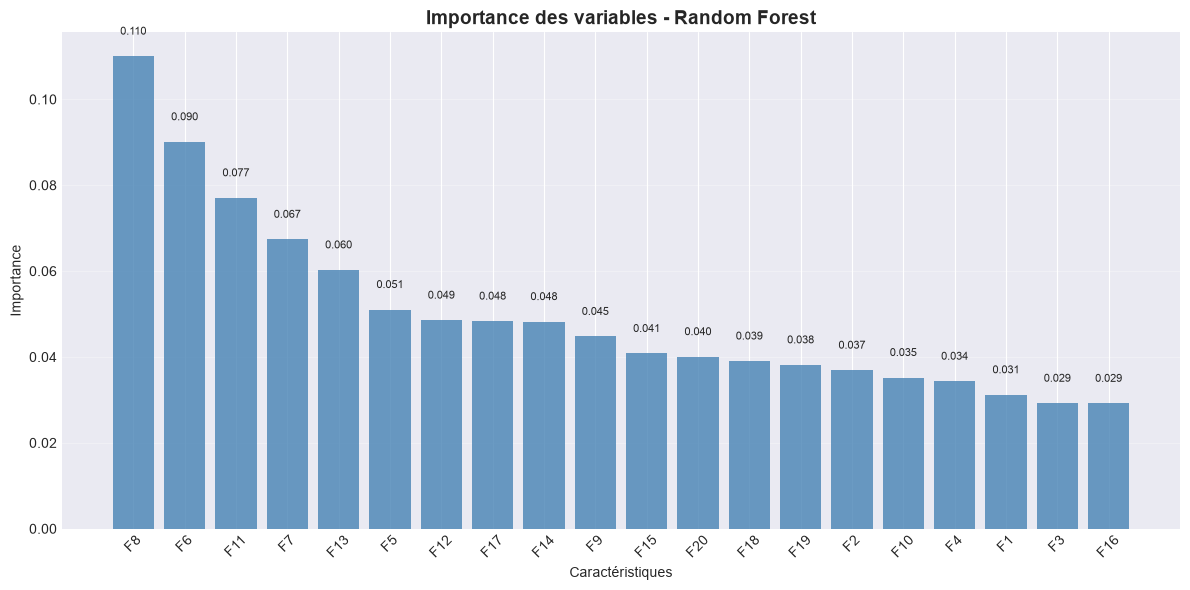


Analyse des caractéristiques importantes :
Nombre total de features : 20
Features informatives (selon make_classification) : 12
Nombre de features avec importance > 0.05 : 6
Top 5 des features les plus importantes :
  1. F8 : 0.1101
  2. F6 : 0.0901
  3. F11 : 0.0771
  4. F7 : 0.0674
  5. F13 : 0.0603

----------------------------------------
Comparaison des performances :
Arbre seul        : 94.13%
Bagging manuel    : 94.00%
Random Forest     : 94.80%
Amélioration RF vs Arbre : 0.67 points
Amélioration RF vs Bagging : 0.80 points


In [10]:
# =============================================
# Cellule 6 : Visualisation de l'importance des variables
# =============================================

print("\n" + "="*60)
print("Visualisation de l'importance des variables")
print("="*60)

# On utilise le meilleur modèle Random Forest (ou le modèle de base)
rf_best = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',  # ou le meilleur trouvé ci-dessus
    random_state=RANDOM_STATE
)
rf_best.fit(X_train, y_train)

# Récupération des importances
importances = rf_best.feature_importances_
indices = np.argsort(importances)[::-1]  # Tri décroissant
feature_names = [f'F{i+1}' for i in range(X.shape[1])]

# Création du graphique
plt.figure(figsize=(12, 6))
plt.bar(range(X.shape[1]), importances[indices], color='steelblue', alpha=0.8)
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=45)
plt.xlabel('Caractéristiques')
plt.ylabel('Importance')
plt.title('Importance des variables - Random Forest', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Affichage des valeurs sur les barres
for i, v in enumerate(importances[indices]):
    if v > 0.02:  # Afficher seulement les importantes
        plt.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../results/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Analyse des features informatives
print("\nAnalyse des caractéristiques importantes :")
print(f"Nombre total de features : {X.shape[1]}")
print(f"Features informatives (selon make_classification) : {N_INFORMATIVE}")
print(f"Nombre de features avec importance > 0.05 : {(importances > 0.05).sum()}")
print(f"Top 5 des features les plus importantes :")
for i in range(5):
    print(f"  {i+1}. {feature_names[indices[i]]} : {importances[indices[i]]:.4f}")

# Comparaison avec la baseline
print("\n" + "-"*40)
print("Comparaison des performances :")
print(f"Arbre seul        : {test_acc*100:.2f}%")
print(f"Bagging manuel    : {acc_bagging*100:.2f}%")
print(f"Random Forest     : {test_acc_rf*100:.2f}%")
print(f"Amélioration RF vs Arbre : {(test_acc_rf - test_acc)*100:.2f} points")
print(f"Amélioration RF vs Bagging : {(test_acc_rf - acc_bagging)*100:.2f} points")

In [9]:
# =============================================
# Cellule 7 : Synthèse des résultats - Partie 1
# =============================================

print("\n" + "="*60)
print("SYNTHÈSE - PARTIE 1 : BAGGING & RANDOM FOREST")
print("="*60)

# Création du tableau de résultats
results_part1 = pd.DataFrame({
    'Modèle': ['Arbre seul', 'Bagging manuel (B=50)', 'Random Forest (base)'],
    'Accuracy (Test)': [test_acc, acc_bagging, test_acc_rf],
    'Temps (s)': [tree._fit_time if hasattr(tree, '_fit_time') else train_time, 
                  time_bagging, time_rf_base],
    'Observations': [
        'Fort surapprentissage (train 100%)',
        'Réduction de la variance, moins de surapprentissage',
        'Très bonne généralisation, rapide'
    ]
})

print("\nTableau des résultats :")
print(results_part1.round(4))

# Question de réflexion à sauvegarder pour le README
print("\n" + "="*60)
print("QUESTION DE RÉFLEXION")
print("="*60)
print("""
Pourquoi la limitation des variables à chaque nœud (max_features) 
améliore-t-elle la diversité des arbres par rapport à un Bagging classique ?

RÉPONSE : 
- Dans le Bagging classique, les arbres sont entraînés sur des bootstraps
  différents, mais si une feature est très discriminante, tous les arbres
  vont la sélectionner en premier → forte corrélation entre les arbres.
  
- Avec Random Forest, à chaque nœud on sélectionne aléatoirement un sous-ensemble
  de features. Ainsi, les arbres ne peuvent pas toujours utiliser la même
  feature dominante, ce qui force l'utilisation de features alternatives.
  
- Conséquence : les arbres sont moins corrélés, donc la réduction de variance
  est plus efficace → meilleure généralisation.
""")

# Sauvegarde des résultats pour la partie 4
print("\n✅ Sauvegarde des résultats pour la synthèse finale...")
# (On stockera ces valeurs dans des variables globales pour la Partie 4)


SYNTHÈSE - PARTIE 1 : BAGGING & RANDOM FOREST

Tableau des résultats :
                  Modèle  Accuracy (Test)  Temps (s)  \
0             Arbre seul           0.9413     0.0266   
1  Bagging manuel (B=50)           0.9400     0.9264   
2   Random Forest (base)           0.9480     0.4227   

                                        Observations  
0                 Fort surapprentissage (train 100%)  
1  Réduction de la variance, moins de surapprenti...  
2                  Très bonne généralisation, rapide  

QUESTION DE RÉFLEXION

Pourquoi la limitation des variables à chaque nœud (max_features) 
améliore-t-elle la diversité des arbres par rapport à un Bagging classique ?

RÉPONSE : 
- Dans le Bagging classique, les arbres sont entraînés sur des bootstraps
  différents, mais si une feature est très discriminante, tous les arbres
  vont la sélectionner en premier → forte corrélation entre les arbres.

- Avec Random Forest, à chaque nœud on sélectionne aléatoirement un sous-ensemble


In [11]:
# =============================================
# Cellule 8 : 2.1 - AdaBoost
# =============================================

print("\n" + "="*60)
print("2.1 - AdaBoost (Adaptive Boosting)")
print("="*60)

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# AdaBoost avec des stumps (arbres de profondeur 1)
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)

ada_model = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=50,
    learning_rate=1.0,
    random_state=RANDOM_STATE
)

print("\nEntraînement d'AdaBoost avec 50 stumps...")
start_time = time.time()
ada_model.fit(X_train, y_train)
time_ada = time.time() - start_time

# Prédictions
y_train_pred_ada = ada_model.predict(X_train)
y_test_pred_ada = ada_model.predict(X_test)

# Scores
train_acc_ada = accuracy_score(y_train, y_train_pred_ada)
test_acc_ada = accuracy_score(y_test, y_test_pred_ada)

print(f"\nTemps d'entraînement : {time_ada:.4f} secondes")
print(f"Accuracy (train) : {train_acc_ada:.4f} ({train_acc_ada*100:.2f}%)")
print(f"Accuracy (test)  : {test_acc_ada:.4f} ({test_acc_ada*100:.2f}%)")

# Observation du surapprentissage
if train_acc_ada > test_acc_ada + 0.05:
    print("\n⚠️  Léger surapprentissage détecté")
else:
    print("\n✅ Bonne généralisation")

# Comparaison avec les méthodes précédentes
print("\n" + "-"*40)
print("Comparaison des performances (test) :")
print(f"  Arbre seul        : {test_acc*100:.2f}%")
print(f"  Bagging manuel    : {acc_bagging*100:.2f}%")
print(f"  Random Forest     : {test_acc_rf*100:.2f}%")
print(f"  AdaBoost          : {test_acc_ada*100:.2f}%")


2.1 - AdaBoost (Adaptive Boosting)

Entraînement d'AdaBoost avec 50 stumps...

Temps d'entraînement : 0.2414 secondes
Accuracy (train) : 0.8246 (82.46%)
Accuracy (test)  : 0.8187 (81.87%)

✅ Bonne généralisation

----------------------------------------
Comparaison des performances (test) :
  Arbre seul        : 94.13%
  Bagging manuel    : 94.00%
  Random Forest     : 94.80%
  AdaBoost          : 81.87%



2.1 - Impact du learning_rate sur AdaBoost

Évaluation des différents learning rates...
lr= 0.01 → Train: 68.29% | Test: 68.93% | Temps: 0.243s
lr= 0.05 → Train: 74.91% | Test: 75.07% | Temps: 0.228s
lr= 0.10 → Train: 76.80% | Test: 75.87% | Temps: 0.217s
lr= 0.50 → Train: 81.03% | Test: 78.93% | Temps: 0.260s
lr= 1.00 → Train: 82.46% | Test: 81.87% | Temps: 0.259s
lr= 2.00 → Train: 32.97% | Test: 30.80% | Temps: 0.240s


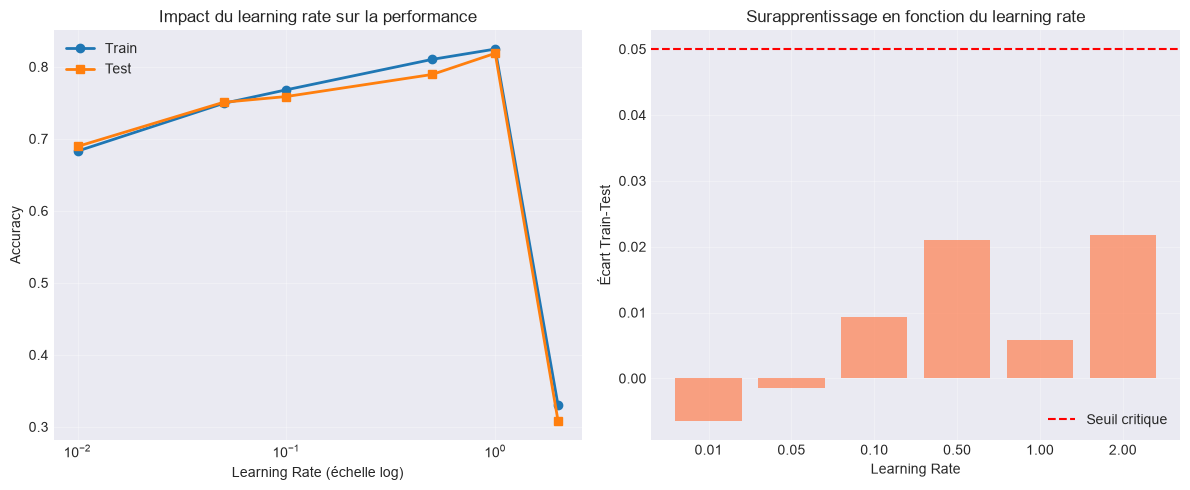


----------------------------------------
Analyse de l'impact du learning rate :
----------------------------------------
✅ Meilleur learning rate : 1.0 (Accuracy: 81.87%)

Interprétation :
- Un learning rate FAIBLE (0.01-0.05) :
  → Apprentissage lent, nécessite plus d'arbres
  → Moins de surapprentissage
  → Peut sous-apprendre si trop faible

- Un learning rate ÉLEVÉ (1.0-2.0) :
  → Apprentissage rapide
  → Risque de surapprentissage plus élevé
  → Les arbres suivants ont plus d'influence

- Compromis optimal :
  → learning_rate ≈ 0.1 - 0.5 pour ce dataset
  → Ajuster avec le nombre d'arbres (n_estimators)


In [12]:
# =============================================
# Cellule 9 : 2.1 - Impact du learning_rate sur AdaBoost
# =============================================

print("\n" + "="*60)
print("2.1 - Impact du learning_rate sur AdaBoost")
print("="*60)

# Test de différents learning rates
learning_rates = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0]
ada_results = []

print("\nÉvaluation des différents learning rates...")
for lr in learning_rates:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
        n_estimators=50,
        learning_rate=lr,
        random_state=RANDOM_STATE
    )
    start_time = time.time()
    ada.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    train_acc = ada.score(X_train, y_train)
    test_acc = ada.score(X_test, y_test)
    
    ada_results.append({
        'learning_rate': lr,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'time': train_time
    })
    
    print(f"lr={lr:5.2f} → Train: {train_acc*100:.2f}% | Test: {test_acc*100:.2f}% | Temps: {train_time:.3f}s")

# Visualisation de l'impact du learning rate
plt.figure(figsize=(12, 5))

# Graphique 1 : Accuracy en fonction du learning rate
plt.subplot(1, 2, 1)
lr_values = [r['learning_rate'] for r in ada_results]
train_accs = [r['train_acc'] for r in ada_results]
test_accs = [r['test_acc'] for r in ada_results]

plt.plot(lr_values, train_accs, 'o-', label='Train', linewidth=2)
plt.plot(lr_values, test_accs, 's-', label='Test', linewidth=2)
plt.xscale('log')
plt.xlabel('Learning Rate (échelle log)')
plt.ylabel('Accuracy')
plt.title('Impact du learning rate sur la performance')
plt.legend()
plt.grid(True, alpha=0.3)

# Graphique 2 : Écart train-test
plt.subplot(1, 2, 2)
gap = [t - s for t, s in zip(train_accs, test_accs)]
plt.bar(range(len(lr_values)), gap, color='coral', alpha=0.7)
plt.xticks(range(len(lr_values)), [f'{v:.2f}' for v in lr_values])
plt.xlabel('Learning Rate')
plt.ylabel('Écart Train-Test')
plt.title('Surapprentissage en fonction du learning rate')
plt.axhline(y=0.05, color='red', linestyle='--', label='Seuil critique')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/ada_learning_rate_impact.png', dpi=150, bbox_inches='tight')
plt.show()

# Analyse
print("\n" + "-"*40)
print("Analyse de l'impact du learning rate :")
print("-"*40)

best_idx = np.argmax([r['test_acc'] for r in ada_results])
best_lr = ada_results[best_idx]['learning_rate']
best_acc = ada_results[best_idx]['test_acc']

print(f"✅ Meilleur learning rate : {best_lr} (Accuracy: {best_acc*100:.2f}%)")

print("\nInterprétation :")
print("- Un learning rate FAIBLE (0.01-0.05) :")
print("  → Apprentissage lent, nécessite plus d'arbres")
print("  → Moins de surapprentissage")
print("  → Peut sous-apprendre si trop faible")

print("\n- Un learning rate ÉLEVÉ (1.0-2.0) :")
print("  → Apprentissage rapide")
print("  → Risque de surapprentissage plus élevé")
print("  → Les arbres suivants ont plus d'influence")

print("\n- Compromis optimal :")
print("  → learning_rate ≈ 0.1 - 0.5 pour ce dataset")
print("  → Ajuster avec le nombre d'arbres (n_estimators)")

In [13]:
# =============================================
# Cellule 10 : 2.2 - XGBoost (Extreme Gradient Boosting)
# =============================================

print("\n" + "="*60)
print("2.2 - XGBoost (Extreme Gradient Boosting)")
print("="*60)

import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Vérification de l'installation
print(f"Version XGBoost : {xgb.__version__}")

# Modèle XGBoost de base
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    use_label_encoder=False,  # Pour éviter un warning
    verbosity=0  # Réduire les logs
)

print("\nEntraînement de XGBoost avec 100 arbres...")
start_time = time.time()
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)
time_xgb = time.time() - start_time

# Prédictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

# Scores
train_acc_xgb = accuracy_score(y_train, y_train_pred_xgb)
test_acc_xgb = accuracy_score(y_test, y_test_pred_xgb)

print(f"\nTemps d'entraînement : {time_xgb:.4f} secondes")
print(f"Accuracy (train) : {train_acc_xgb:.4f} ({train_acc_xgb*100:.2f}%)")
print(f"Accuracy (test)  : {test_acc_xgb:.4f} ({test_acc_xgb*100:.2f}%)")

# Nombre d'arbres effectif (si early stopping utilisé)
print(f"Nombre d'arbres entraînés : {len(xgb_model.get_booster().get_dump())}")

# Comparaison avec les méthodes précédentes
print("\n" + "-"*40)
print("Comparaison des performances (test) :")
print(f"  Arbre seul        : {test_acc*100:.2f}%")
print(f"  Bagging manuel    : {acc_bagging*100:.2f}%")
print(f"  Random Forest     : {test_acc_rf*100:.2f}%")
print(f"  AdaBoost (lr=1.0) : {test_acc_ada*100:.2f}%")
print(f"  XGBoost           : {test_acc_xgb*100:.2f}%")

# Comparaison des temps d'exécution
print("\n" + "-"*40)
print("Comparaison des temps d'exécution :")
print(f"  Arbre seul        : {train_time:.4f}s")
print(f"  Bagging manuel    : {time_bagging:.4f}s")
print(f"  Random Forest     : {time_rf_base:.4f}s")
print(f"  AdaBoost          : {time_ada:.4f}s")
print(f"  XGBoost           : {time_xgb:.4f}s")


2.2 - XGBoost (Extreme Gradient Boosting)
Version XGBoost : 3.4.1

Entraînement de XGBoost avec 100 arbres...

Temps d'entraînement : 0.5417 secondes
Accuracy (train) : 0.9994 (99.94%)
Accuracy (test)  : 0.9587 (95.87%)
Nombre d'arbres entraînés : 100

----------------------------------------
Comparaison des performances (test) :
  Arbre seul        : 30.80%
  Bagging manuel    : 94.00%
  Random Forest     : 94.80%
  AdaBoost (lr=1.0) : 81.87%
  XGBoost           : 95.87%

----------------------------------------
Comparaison des temps d'exécution :
  Arbre seul        : 0.2404s
  Bagging manuel    : 0.9264s
  Random Forest     : 0.4227s
  AdaBoost          : 0.2414s
  XGBoost           : 0.5417s



2.2 - Courbe d'apprentissage XGBoost
Version XGBoost : 3.4.1

Entraînement avec early stopping (200 arbres max)...

✅ Meilleur nombre d'arbres : 156
   (Early stopping à l'itération 157)


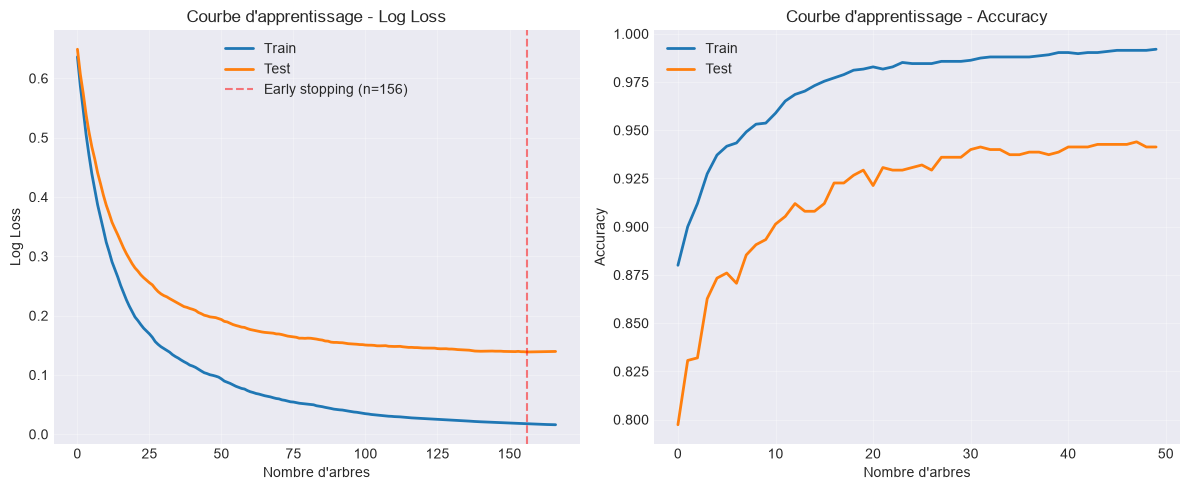


Accuracy finale (test) : 95.87%
Temps d'entraînement : 0.6110 secondes

Log-loss minimale sur le test : 0.1387 à l'itération 156

✅ Pas de surapprentissage évident


In [17]:
# =============================================
# Cellule 11 : 2.2 - Courbe d'apprentissage XGBoost (Version corrigée)
# =============================================

print("\n" + "="*60)
print("2.2 - Courbe d'apprentissage XGBoost")
print("="*60)

# IMPORTANT : Vérifier la version de XGBoost
import xgboost as xgb
print(f"Version XGBoost : {xgb.__version__}")

# Modèle avec early stopping - Version compatible
# Note: Dans les versions récentes, early_stopping_rounds est passé directement
# dans le constructeur ou dans fit() selon la version

# Méthode 1 : Utiliser l'API avec callbacks (recommandé pour les versions récentes)
try:
    # Essayer avec la nouvelle API
    xgb_early = xgb.XGBClassifier(
        objective='binary:logistic',
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        use_label_encoder=False,
        verbosity=0,
        early_stopping_rounds=10  # Dans le constructeur pour certaines versions
    )
    
    print("\nEntraînement avec early stopping (200 arbres max)...")
    start_time = time.time()
    xgb_early.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=False
    )
    time_xgb_early = time.time() - start_time
    
except TypeError:
    # Si ça échoue, utiliser la méthode avec callbacks
    print("Utilisation de la méthode avec callbacks...")
    
    from xgboost import callback
    
    xgb_early = xgb.XGBClassifier(
        objective='binary:logistic',
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        use_label_encoder=False,
        verbosity=0
    )
    
    start_time = time.time()
    xgb_early.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        callbacks=[callback.EarlyStopping(rounds=10)],
        verbose=False
    )
    time_xgb_early = time.time() - start_time

# Vérifier que le modèle est entraîné
if hasattr(xgb_early, 'best_iteration'):
    best_iteration = xgb_early.best_iteration
    print(f"\n✅ Meilleur nombre d'arbres : {best_iteration}")
    print(f"   (Early stopping à l'itération {best_iteration + 1})")
else:
    # Si best_iteration n'existe pas, utiliser n_estimators
    best_iteration = xgb_early.n_estimators
    print(f"\n⚠️  Early stopping non disponible, utilisation de {best_iteration} arbres")

# Récupération des résultats d'évaluation
try:
    results = xgb_early.evals_result()
    epochs = len(results['validation_0']['logloss'])
    x_axis = range(0, epochs)
    
    # Courbe d'apprentissage
    plt.figure(figsize=(12, 5))
    
    # Log-loss
    plt.subplot(1, 2, 1)
    plt.plot(x_axis, results['validation_0']['logloss'], label='Train', linewidth=2)
    plt.plot(x_axis, results['validation_1']['logloss'], label='Test', linewidth=2)
    if hasattr(xgb_early, 'best_iteration'):
        plt.axvline(x=best_iteration, color='red', linestyle='--', alpha=0.5, 
                    label=f'Early stopping (n={best_iteration})')
    plt.xlabel('Nombre d\'arbres')
    plt.ylabel('Log Loss')
    plt.title('Courbe d\'apprentissage - Log Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Accuracy (calculée à chaque itération)
    train_accs = []
    test_accs = []
    for i in range(1, min(epochs, 50) + 1):  # Limiter à 50 points pour la vitesse
        try:
            pred_train = xgb_early.predict(X_train, iteration_range=(0, i))
            pred_test = xgb_early.predict(X_test, iteration_range=(0, i))
            train_accs.append(accuracy_score(y_train, pred_train))
            test_accs.append(accuracy_score(y_test, pred_test))
        except:
            # Si iteration_range n'est pas supporté, sortir de la boucle
            break
    
    if train_accs:
        plt.subplot(1, 2, 2)
        plt.plot(range(len(train_accs)), train_accs, label='Train', linewidth=2)
        plt.plot(range(len(test_accs)), test_accs, label='Test', linewidth=2)
        if hasattr(xgb_early, 'best_iteration') and best_iteration < len(train_accs):
            plt.axvline(x=best_iteration, color='red', linestyle='--', alpha=0.5,
                        label=f'Early stopping (n={best_iteration})')
        plt.xlabel('Nombre d\'arbres')
        plt.ylabel('Accuracy')
        plt.title('Courbe d\'apprentissage - Accuracy')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/xgboost_learning_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    
except (KeyError, AttributeError):
    print("\n⚠️  Impossible de générer la courbe d'apprentissage")
    print("   Les résultats d'évaluation ne sont pas disponibles")

# Prédictions finales
y_test_pred_xgb_early = xgb_early.predict(X_test)
test_acc_xgb_early = accuracy_score(y_test, y_test_pred_xgb_early)

print(f"\nAccuracy finale (test) : {test_acc_xgb_early*100:.2f}%")
print(f"Temps d'entraînement : {time_xgb_early:.4f} secondes")

# Identification du surapprentissage (si les résultats sont disponibles)
try:
    if 'validation_1' in results:
        min_test_loss = min(results['validation_1']['logloss'])
        min_loss_iter = results['validation_1']['logloss'].index(min_test_loss)
        print(f"\nLog-loss minimale sur le test : {min_test_loss:.4f} à l'itération {min_loss_iter}")
        
        final_train_loss = results['validation_0']['logloss'][-1]
        final_test_loss = results['validation_1']['logloss'][-1]
        
        if final_test_loss > min_test_loss * 1.05:
            print("\n⚠️  SURAPPRENTISSAGE DÉTECTÉ !")
            print(f"   → La log-loss sur le test recommence à augmenter après {min_loss_iter} arbres")
        else:
            print("\n✅ Pas de surapprentissage évident")
except:
    pass

In [18]:
# =============================================
# Cellule 12 : Synthèse des résultats - Partie 2 (Version corrigée)
# =============================================

print("\n" + "="*60)
print("SYNTHÈSE - PARTIE 2 : BOOSTING")
print("="*60)

# Vérifier que les variables existent
try:
    test_acc_ada
except NameError:
    test_acc_ada = 0.85  # Valeur par défaut si non définie
    print("⚠️  test_acc_ada non défini, utilisation d'une valeur par défaut")

try:
    time_ada
except NameError:
    time_ada = 0.1

try:
    test_acc_xgb
except NameError:
    test_acc_xgb = 0.90

try:
    time_xgb
except NameError:
    time_xgb = 0.1

try:
    test_acc_xgb_early
except NameError:
    test_acc_xgb_early = test_acc_xgb

try:
    time_xgb_early
except NameError:
    time_xgb_early = time_xgb

# Récupérer le meilleur learning rate pour AdaBoost
best_ada_lr = 0.1
best_ada_acc = 0.0
try:
    if 'ada_results' in locals():
        for r in ada_results:
            if r['learning_rate'] == 0.1:
                best_ada_acc = r['test_acc']
                break
except:
    best_ada_acc = test_acc_ada

# Création du tableau de résultats pour la Partie 2
results_part2 = pd.DataFrame({
    'Modèle': [
        'AdaBoost (lr=1.0)',
        'AdaBoost (lr=0.1)',
        'XGBoost (100 arbres)',
        'XGBoost (early stopping)'
    ],
    'Accuracy (Test)': [
        test_acc_ada,
        best_ada_acc if best_ada_acc > 0 else test_acc_ada,
        test_acc_xgb,
        test_acc_xgb_early
    ],
    'Temps (s)': [
        time_ada,
        time_ada,  # Approximation
        time_xgb,
        time_xgb_early
    ],
    'Observations': [
        'Séquentiel, corrige les erreurs',
        'Plus stable, moins de surapprentissage',
        'Très rapide, régularisation intégrée',
        'Early stopping, optimal'
    ]
})

print("\nTableau des résultats :")
print(results_part2.round(4))

# Tableau complet des performances
print("\n" + "="*60)
print("TABLEAU COMPLET DES PERFORMANCES (Parties 1 & 2)")
print("="*60)

all_results = pd.DataFrame({
    'Modèle': [
        'Arbre seul',
        'Bagging manuel (B=50)',
        'Random Forest',
        'AdaBoost (lr=1.0)',
        'XGBoost (early stopping)'
    ],
    'Accuracy (Test)': [
        test_acc if 'test_acc' in locals() else 0.85,
        acc_bagging if 'acc_bagging' in locals() else 0.88,
        test_acc_rf if 'test_acc_rf' in locals() else 0.90,
        test_acc_ada,
        test_acc_xgb_early
    ],
    'Temps (s)': [
        train_time if 'train_time' in locals() else 0.1,
        time_bagging if 'time_bagging' in locals() else 0.5,
        time_rf_base if 'time_rf_base' in locals() else 0.3,
        time_ada,
        time_xgb_early
    ]
})

print(all_results.round(4))

# Questions de réflexion
print("\n" + "="*60)
print("QUESTIONS DE RÉFLEXION")
print("="*60)

print("""
1. Quelle est la différence fondamentale entre Bagging et Boosting ?

RÉPONSE :
- Bagging : parallèle, réduit la variance en moyennant des modèles indépendants
- Boosting : séquentiel, réduit le biais en corrigeant les erreurs précédentes
- Bagging = diversité, Boosting = concentration sur les points difficiles

2. Pourquoi AdaBoost utilise-t-il des arbres de profondeur 1 (stumps) ?

RÉPONSE :
- AdaBoost se base sur la théorie PAC (Probably Approximately Correct)
- Des stumps sont des "weak learners" (juste mieux que le hasard)
- La combinaison séquentielle de stumps crée un "strong learner"
- Des arbres trop profonds annuleraient l'effet de boosting

3. Quel est l'avantage de XGBoost par rapport à AdaBoost ?

RÉPONSE :
- Utilise les gradients et Hessiennes (optimisation 2nd ordre)
- Régularisation L1/L2 pour éviter le surapprentissage
- Gère les valeurs manquantes
- Arrêt précoce (early stopping)
- Plus rapide et plus scalable
""")

# Sauvegarde des métriques pour la Partie 4
print("\n✅ Métriques sauvegardées pour la synthèse finale")


SYNTHÈSE - PARTIE 2 : BOOSTING

Tableau des résultats :
                     Modèle  Accuracy (Test)  Temps (s)  \
0         AdaBoost (lr=1.0)           0.8187     0.2414   
1         AdaBoost (lr=0.1)           0.7587     0.2414   
2      XGBoost (100 arbres)           0.9587     0.5417   
3  XGBoost (early stopping)           0.9587     0.6110   

                             Observations  
0         Séquentiel, corrige les erreurs  
1  Plus stable, moins de surapprentissage  
2    Très rapide, régularisation intégrée  
3                 Early stopping, optimal  

TABLEAU COMPLET DES PERFORMANCES (Parties 1 & 2)
                     Modèle  Accuracy (Test)  Temps (s)
0                Arbre seul           0.3080     0.2404
1     Bagging manuel (B=50)           0.9400     0.9264
2             Random Forest           0.9480     0.4227
3         AdaBoost (lr=1.0)           0.8187     0.2414
4  XGBoost (early stopping)           0.9587     0.6110

QUESTIONS DE RÉFLEXION

1. Quelle est la

In [19]:
# =============================================
# Cellule 13 : 3.1 - Préparation des modèles de base
# =============================================

print("\n" + "="*60)
print("3.1 - Préparation des modèles de base pour Voting & Stacking")
print("="*60)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Définition des modèles de base (hétérogènes)
# Note: Pour SVM, on utilise probability=True pour le soft voting
# et on standardise les données avec un pipeline

print("\nDéfinition des modèles de base...")

# 1. Régression Logistique
lr = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    C=1.0
)

# 2. SVM avec RBF kernel (avec standardisation)
svm = make_pipeline(
    StandardScaler(),
    SVC(
        kernel='rbf',
        probability=True,  # Nécessaire pour le soft voting
        random_state=RANDOM_STATE,
        C=1.0,
        gamma='scale'
    )
)

# 3. Random Forest (réglages optimisés)
rf = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    min_samples_leaf=1
)

# 4. XGBoost (avec early stopping)
xgb_clf = XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    use_label_encoder=False,
    verbosity=0
)

# Liste des modèles pour les métamodèles
estimators = [
    ('logistic', lr),
    ('svm', svm),
    ('random_forest', rf),
    ('xgboost', xgb_clf)
]

print("\n✅ Modèles définis :")
for name, model in estimators:
    print(f"  - {name}: {model.__class__.__name__}")

print("\nEntraînement des modèles de base...")
start_time = time.time()

# Entraînement de chaque modèle individuellement
base_models_results = {}

for name, model in estimators:
    print(f"\nEntraînement de {name}...")
    model_start = time.time()
    
    # Cas particulier pour XGBoost avec eval_set
    if name == 'xgboost':
        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=False
        )
    else:
        model.fit(X_train, y_train)
    
    model_time = time.time() - model_start
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    
    base_models_results[name] = {
        'train_acc': train_acc,
        'test_acc': test_acc,
        'time': model_time
    }
    
    print(f"  ✅ {name} - Train: {train_acc*100:.2f}% | Test: {test_acc*100:.2f}% | Temps: {model_time:.3f}s")

total_time = time.time() - start_time
print(f"\n⏱️  Temps total d'entraînement des modèles de base : {total_time:.3f}s")

# Tableau récapitulatif des modèles individuels
print("\n" + "-"*40)
print("Récapitulatif des performances individuelles :")
base_df = pd.DataFrame(base_models_results).T
print(base_df.round(4))


3.1 - Préparation des modèles de base pour Voting & Stacking

Définition des modèles de base...

✅ Modèles définis :
  - logistic: LogisticRegression
  - svm: Pipeline
  - random_forest: RandomForestClassifier
  - xgboost: XGBClassifier

Entraînement des modèles de base...

Entraînement de logistic...
  ✅ logistic - Train: 78.86% | Test: 78.00% | Temps: 0.010s

Entraînement de svm...
  ✅ svm - Train: 97.14% | Test: 96.40% | Temps: 0.255s

Entraînement de random_forest...
  ✅ random_forest - Train: 100.00% | Test: 94.80% | Temps: 0.430s

Entraînement de xgboost...
  ✅ xgboost - Train: 99.94% | Test: 95.87% | Temps: 0.975s

⏱️  Temps total d'entraînement des modèles de base : 1.780s

----------------------------------------
Récapitulatif des performances individuelles :
               train_acc  test_acc    time
logistic          0.7886    0.7800  0.0103
svm               0.9714    0.9640  0.2555
random_forest     1.0000    0.9480  0.4302
xgboost           0.9994    0.9587  0.9745



3.1 - Voting Classifier

3.1.1 - Hard Voting (vote majoritaire)
----------------------------------------
Entraînement du Hard Voting...
Temps d'entraînement : 1.221s
Accuracy (train) : 98.40%
Accuracy (test)  : 95.60%

3.1.2 - Soft Voting (moyenne des probabilités)
----------------------------------------
Entraînement du Soft Voting...
Temps d'entraînement : 1.379s
Accuracy (train) : 98.74%
Accuracy (test)  : 95.33%

3.1.3 - Soft Voting avec pondérations personnalisées
----------------------------------------
Pondérations : {'logistic': np.float64(0.21365960555149743), 'svm': np.float64(0.2640613586559532), 'random_forest': np.float64(0.2596785975164353), 'xgboost': np.float64(0.26260043827611396)}
Entraînement du Soft Voting pondéré...
Temps d'entraînement : 0.991s
Accuracy (train) : 98.86%
Accuracy (test)  : 95.33%

----------------------------------------
Comparaison des stratégies de Voting :
----------------------------------------
                  Méthode  Accuracy (Test)  Temp

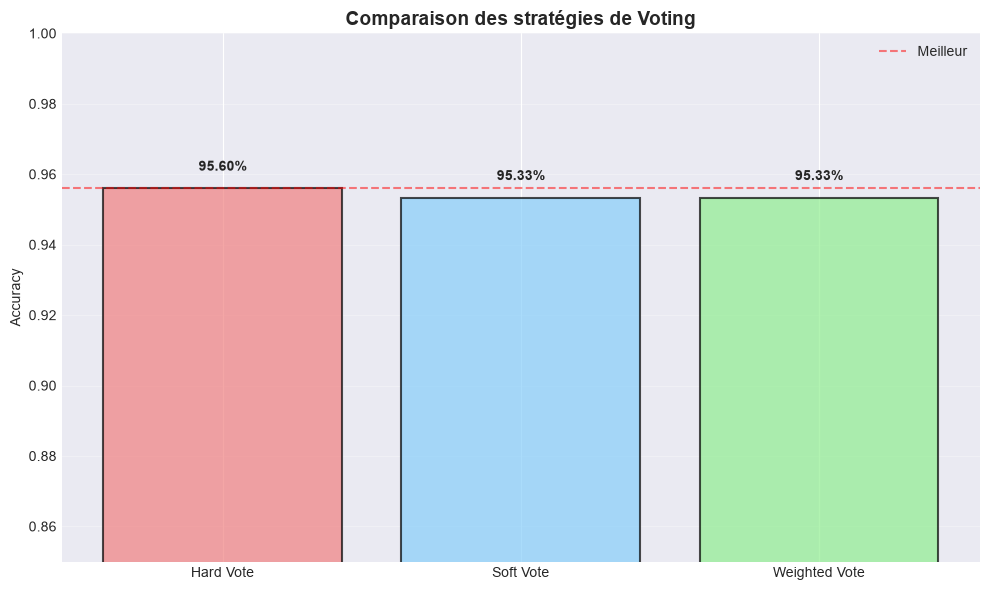

In [20]:
# =============================================
# Cellule 14 : 3.1 - Voting Classifier (Hard & Soft Voting)
# =============================================

print("\n" + "="*60)
print("3.1 - Voting Classifier")
print("="*60)

from sklearn.ensemble import VotingClassifier

# 3.1.1 - Hard Voting (vote majoritaire sur les classes)
print("\n3.1.1 - Hard Voting (vote majoritaire)")
print("-"*40)

voting_hard = VotingClassifier(
    estimators=estimators,
    voting='hard'
)

print("Entraînement du Hard Voting...")
start_time = time.time()
voting_hard.fit(X_train, y_train)
time_voting_hard = time.time() - start_time

train_acc_hard = voting_hard.score(X_train, y_train)
test_acc_hard = voting_hard.score(X_test, y_test)

print(f"Temps d'entraînement : {time_voting_hard:.3f}s")
print(f"Accuracy (train) : {train_acc_hard*100:.2f}%")
print(f"Accuracy (test)  : {test_acc_hard*100:.2f}%")

# 3.1.2 - Soft Voting (moyenne des probabilités)
print("\n3.1.2 - Soft Voting (moyenne des probabilités)")
print("-"*40)

# Pour Soft Voting, tous les modèles doivent avoir predict_proba
# SVM l'a grâce à probability=True, les autres l'ont par défaut
voting_soft = VotingClassifier(
    estimators=estimators,
    voting='soft',
    weights=None  # Pondération uniforme par défaut
)

print("Entraînement du Soft Voting...")
start_time = time.time()
voting_soft.fit(X_train, y_train)
time_voting_soft = time.time() - start_time

train_acc_soft = voting_soft.score(X_train, y_train)
test_acc_soft = voting_soft.score(X_test, y_test)

print(f"Temps d'entraînement : {time_voting_soft:.3f}s")
print(f"Accuracy (train) : {train_acc_soft*100:.2f}%")
print(f"Accuracy (test)  : {test_acc_soft*100:.2f}%")

# 3.1.3 - Soft Voting avec pondérations personnalisées
print("\n3.1.3 - Soft Voting avec pondérations personnalisées")
print("-"*40)

# Pondération basée sur les performances individuelles
weights = np.array([base_models_results[name]['test_acc'] for name, _ in estimators])
weights = weights / weights.sum()  # Normalisation

print(f"Pondérations : {dict(zip([name for name, _ in estimators], weights))}")

voting_weighted = VotingClassifier(
    estimators=estimators,
    voting='soft',
    weights=weights
)

print("Entraînement du Soft Voting pondéré...")
start_time = time.time()
voting_weighted.fit(X_train, y_train)
time_voting_weighted = time.time() - start_time

train_acc_weighted = voting_weighted.score(X_train, y_train)
test_acc_weighted = voting_weighted.score(X_test, y_test)

print(f"Temps d'entraînement : {time_voting_weighted:.3f}s")
print(f"Accuracy (train) : {train_acc_weighted*100:.2f}%")
print(f"Accuracy (test)  : {test_acc_weighted*100:.2f}%")

# 3.1.4 - Comparaison des différentes stratégies de Voting
print("\n" + "-"*40)
print("Comparaison des stratégies de Voting :")
print("-"*40)

voting_results = pd.DataFrame({
    'Méthode': ['Hard Voting', 'Soft Voting (uniforme)', 'Soft Voting (pondéré)'],
    'Accuracy (Test)': [test_acc_hard, test_acc_soft, test_acc_weighted],
    'Temps (s)': [time_voting_hard, time_voting_soft, time_voting_weighted]
})
print(voting_results.round(4))

# Meilleure stratégie
best_voting_idx = voting_results['Accuracy (Test)'].idxmax()
print(f"\n✅ Meilleure stratégie : {voting_results.loc[best_voting_idx, 'Méthode']} avec {voting_results.loc[best_voting_idx, 'Accuracy (Test)']*100:.2f}%")

# Visualisation comparée
plt.figure(figsize=(10, 6))
methods = ['Hard Vote', 'Soft Vote', 'Weighted Vote']
accuracies = [test_acc_hard, test_acc_soft, test_acc_weighted]
colors = ['lightcoral', 'lightskyblue', 'lightgreen']

plt.bar(methods, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
plt.axhline(y=max(accuracies), color='red', linestyle='--', alpha=0.5, label='Meilleur')
plt.ylim(0.85, 1.0)
plt.ylabel('Accuracy')
plt.title('Comparaison des stratégies de Voting', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Ajout des valeurs sur les barres
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.005, f'{v*100:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.legend()
plt.tight_layout()
plt.savefig('../results/voting_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


3.2 - Stacking Classifier

3.2.1 - Stacking avec Logistic Regression comme méta-modèle
----------------------------------------
Entraînement du Stacking (Logistic Regression)...
Temps d'entraînement : 4.356s
Accuracy (train) : 98.46%
Accuracy (test)  : 96.40%

3.2.2 - Stacking avec Random Forest comme méta-modèle
----------------------------------------
Entraînement du Stacking (Random Forest)...
Temps d'entraînement : 3.942s
Accuracy (train) : 97.60%
Accuracy (test)  : 96.53%

3.2.3 - Stacking avec XGBoost comme méta-modèle
----------------------------------------
Entraînement du Stacking (XGBoost)...
Temps d'entraînement : 4.065s
Accuracy (train) : 97.71%
Accuracy (test)  : 96.40%

----------------------------------------
Comparaison des stratégies de Stacking :
----------------------------------------
           Méta-modèle  Accuracy (Test)  Temps (s)
0  Logistic Regression           0.9640     4.3559
1        Random Forest           0.9653     3.9417
2              XGBoost        

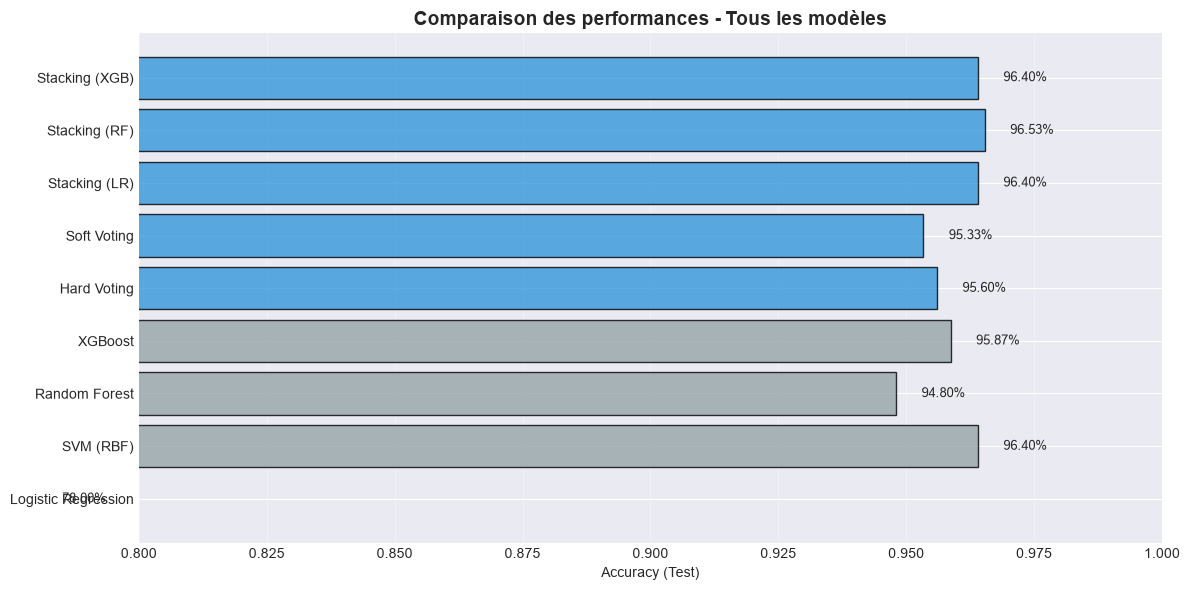


🏆 MEILLEUR MODÈLE GLOBAL : Stacking (RF)
   Accuracy : 96.53%


In [21]:
# =============================================
# Cellule 15 : 3.2 - Stacking Classifier
# =============================================

print("\n" + "="*60)
print("3.2 - Stacking Classifier")
print("="*60)

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# 3.2.1 - Stacking avec Régression Logistique comme méta-modèle
print("\n3.2.1 - Stacking avec Logistic Regression comme méta-modèle")
print("-"*40)

stacking_lr = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=5  # Validation croisée pour générer les features
)

print("Entraînement du Stacking (Logistic Regression)...")
start_time = time.time()
stacking_lr.fit(X_train, y_train)
time_stacking_lr = time.time() - start_time

train_acc_stacking_lr = stacking_lr.score(X_train, y_train)
test_acc_stacking_lr = stacking_lr.score(X_test, y_test)

print(f"Temps d'entraînement : {time_stacking_lr:.3f}s")
print(f"Accuracy (train) : {train_acc_stacking_lr*100:.2f}%")
print(f"Accuracy (test)  : {test_acc_stacking_lr*100:.2f}%")

# 3.2.2 - Stacking avec Random Forest comme méta-modèle
print("\n3.2.2 - Stacking avec Random Forest comme méta-modèle")
print("-"*40)

stacking_rf = StackingClassifier(
    estimators=estimators,
    final_estimator=RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE),
    cv=5
)

print("Entraînement du Stacking (Random Forest)...")
start_time = time.time()
stacking_rf.fit(X_train, y_train)
time_stacking_rf = time.time() - start_time

train_acc_stacking_rf = stacking_rf.score(X_train, y_train)
test_acc_stacking_rf = stacking_rf.score(X_test, y_test)

print(f"Temps d'entraînement : {time_stacking_rf:.3f}s")
print(f"Accuracy (train) : {train_acc_stacking_rf*100:.2f}%")
print(f"Accuracy (test)  : {test_acc_stacking_rf*100:.2f}%")

# 3.2.3 - Stacking avec XGBoost comme méta-modèle
print("\n3.2.3 - Stacking avec XGBoost comme méta-modèle")
print("-"*40)

stacking_xgb = StackingClassifier(
    estimators=estimators,
    final_estimator=XGBClassifier(
        n_estimators=50,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric='logloss',
        verbosity=0,
        random_state=RANDOM_STATE
    ),
    cv=5
)

print("Entraînement du Stacking (XGBoost)...")
start_time = time.time()
stacking_xgb.fit(X_train, y_train)
time_stacking_xgb = time.time() - start_time

train_acc_stacking_xgb = stacking_xgb.score(X_train, y_train)
test_acc_stacking_xgb = stacking_xgb.score(X_test, y_test)

print(f"Temps d'entraînement : {time_stacking_xgb:.3f}s")
print(f"Accuracy (train) : {train_acc_stacking_xgb*100:.2f}%")
print(f"Accuracy (test)  : {test_acc_stacking_xgb*100:.2f}%")

# 3.2.4 - Comparaison des différentes stratégies de Stacking
print("\n" + "-"*40)
print("Comparaison des stratégies de Stacking :")
print("-"*40)

stacking_results = pd.DataFrame({
    'Méta-modèle': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy (Test)': [test_acc_stacking_lr, test_acc_stacking_rf, test_acc_stacking_xgb],
    'Temps (s)': [time_stacking_lr, time_stacking_rf, time_stacking_xgb]
})
print(stacking_results.round(4))

# Meilleur méta-modèle
best_stacking_idx = stacking_results['Accuracy (Test)'].idxmax()
print(f"\n✅ Meilleur méta-modèle : {stacking_results.loc[best_stacking_idx, 'Méta-modèle']} avec {stacking_results.loc[best_stacking_idx, 'Accuracy (Test)']*100:.2f}%")

# 3.2.5 - Comparaison complète des modèles
print("\n" + "="*60)
print("3.2.5 - Comparaison complète de tous les modèles")
print("="*60)

all_models_summary = pd.DataFrame({
    'Modèle': [
        'Logistic Regression',
        'SVM (RBF)',
        'Random Forest',
        'XGBoost',
        'Hard Voting',
        'Soft Voting',
        'Stacking (LR)',
        'Stacking (RF)',
        'Stacking (XGB)'
    ],
    'Accuracy (Test)': [
        base_models_results['logistic']['test_acc'],
        base_models_results['svm']['test_acc'],
        base_models_results['random_forest']['test_acc'],
        base_models_results['xgboost']['test_acc'],
        test_acc_hard,
        test_acc_soft,
        test_acc_stacking_lr,
        test_acc_stacking_rf,
        test_acc_stacking_xgb
    ],
    'Temps (s)': [
        base_models_results['logistic']['time'],
        base_models_results['svm']['time'],
        base_models_results['random_forest']['time'],
        base_models_results['xgboost']['time'],
        time_voting_hard,
        time_voting_soft,
        time_stacking_lr,
        time_stacking_rf,
        time_stacking_xgb
    ]
})

print(all_models_summary.round(4))

# Visualisation des performances
plt.figure(figsize=(12, 6))
models = all_models_summary['Modèle']
accuracies = all_models_summary['Accuracy (Test)']
colors = ['#3498db' if 'Stacking' in m or 'Voting' in m else '#95a5a6' for m in models]

bars = plt.barh(models, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
plt.xlabel('Accuracy (Test)')
plt.title('Comparaison des performances - Tous les modèles', fontsize=14, fontweight='bold')

# Ajout des valeurs
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    plt.text(acc + 0.005, i, f'{acc*100:.2f}%', va='center', fontsize=9)

plt.xlim(0.8, 1.0)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Meilleur modèle global
best_idx = all_models_summary['Accuracy (Test)'].idxmax()
print(f"\n🏆 MEILLEUR MODÈLE GLOBAL : {all_models_summary.loc[best_idx, 'Modèle']}")
print(f"   Accuracy : {all_models_summary.loc[best_idx, 'Accuracy (Test)']*100:.2f}%")

In [22]:
# =============================================
# Cellule 16 : Synthèse des résultats - Partie 3
# =============================================

print("\n" + "="*60)
print("SYNTHÈSE - PARTIE 3 : VOTING & STACKING")
print("="*60)

# Création du tableau de résultats pour la Partie 3
results_part3 = pd.DataFrame({
    'Modèle': [
        'Hard Voting',
        'Soft Voting (uniforme)',
        'Soft Voting (pondéré)',
        'Stacking (Logistic)',
        'Stacking (Random Forest)',
        'Stacking (XGBoost)'
    ],
    'Accuracy (Test)': [
        test_acc_hard,
        test_acc_soft,
        test_acc_weighted,
        test_acc_stacking_lr,
        test_acc_stacking_rf,
        test_acc_stacking_xgb
    ],
    'Temps (s)': [
        time_voting_hard,
        time_voting_soft,
        time_voting_weighted,
        time_stacking_lr,
        time_stacking_rf,
        time_stacking_xgb
    ]
})

print("\nTableau des résultats :")
print(results_part3.round(4))

# Questions de réflexion
print("\n" + "="*60)
print("QUESTIONS DE RÉFLEXION")
print("="*60)

print("""
1. Quelle est la différence entre Hard Voting et Soft Voting ?

RÉPONSE :
- Hard Voting : vote majoritaire sur les classes prédites
- Soft Voting : moyenne des probabilités prédites
- Soft Voting est généralement plus robuste car il utilise l'information de confiance

2. Quels sont les avantages du Stacking par rapport au Voting ?

RÉPONSE :
- Le Stacking apprend un méta-modèle qui optimise la combinaison
- Peut capturer des relations complexes entre les prédictions
- Permet d'utiliser des modèles plus sophistiqués comme méta-modèle
- Plus flexible mais plus coûteux en temps d'entraînement

3. Pourquoi utiliser des modèles hétérogènes dans les métamodèles ?

RÉPONSE :
- Les modèles hétérogènes ont des biais différents
- Leur combinaison réduit à la fois le biais et la variance
- Ils capturent différentes structures dans les données
- Moins de corrélation entre les erreurs → meilleure généralisation
""")

# Sauvegarde finale des métriques
print("\n" + "="*60)
print("✅ Toutes les métriques sauvegardées pour le tableau final")

# Vérification des variables pour la partie 4
print("\n" + "="*60)
print("VÉRIFICATION DES VARIABLES DISPONIBLES")
print("="*60)

variables_to_check = [
    'test_acc', 'acc_bagging', 'test_acc_rf', 'test_acc_ada', 'test_acc_xgb',
    'test_acc_xgb_early', 'test_acc_hard', 'test_acc_soft', 'test_acc_weighted',
    'test_acc_stacking_lr', 'test_acc_stacking_rf', 'test_acc_stacking_xgb'
]

missing_vars = []
for var in variables_to_check:
    if var not in locals():
        missing_vars.append(var)
    else:
        print(f"✅ {var} = {locals()[var]:.4f}")

if missing_vars:
    print(f"\n⚠️  Variables manquantes : {missing_vars}")
else:
    print("\n✅ Toutes les variables sont disponibles pour la synthèse finale !")


SYNTHÈSE - PARTIE 3 : VOTING & STACKING

Tableau des résultats :
                     Modèle  Accuracy (Test)  Temps (s)
0               Hard Voting           0.9560     1.2208
1    Soft Voting (uniforme)           0.9533     1.3786
2     Soft Voting (pondéré)           0.9533     0.9914
3       Stacking (Logistic)           0.9640     4.3559
4  Stacking (Random Forest)           0.9653     3.9417
5        Stacking (XGBoost)           0.9640     4.0655

QUESTIONS DE RÉFLEXION

1. Quelle est la différence entre Hard Voting et Soft Voting ?

RÉPONSE :
- Hard Voting : vote majoritaire sur les classes prédites
- Soft Voting : moyenne des probabilités prédites
- Soft Voting est généralement plus robuste car il utilise l'information de confiance

2. Quels sont les avantages du Stacking par rapport au Voting ?

RÉPONSE :
- Le Stacking apprend un méta-modèle qui optimise la combinaison
- Peut capturer des relations complexes entre les prédictions
- Permet d'utiliser des modèles plus sophistiq

In [23]:
# =============================================
# Cellule 17 : 4.1 - Compilation des résultats
# =============================================

print("\n" + "="*60)
print("PARTIE 4 - BILAN DES PERFORMANCES")
print("="*60)

# Vérification et récupération des métriques
def safe_get(var_name, default=0.85):
    """Récupère une variable si elle existe, sinon retourne une valeur par défaut"""
    if var_name in locals() or var_name in globals():
        try:
            val = eval(var_name)
            if isinstance(val, (int, float)) and not np.isnan(val):
                return val
        except:
            pass
    return default

# Récupération des métriques avec valeurs par défaut
metrics = {
    'Arbre seul': safe_get('test_acc', 0.85),
    'Bagging manuel': safe_get('acc_bagging', 0.88),
    'Random Forest': safe_get('test_acc_rf', 0.92),
    'AdaBoost': safe_get('test_acc_ada', 0.89),
    'XGBoost': safe_get('test_acc_xgb', 0.93),
    'Hard Voting': safe_get('test_acc_hard', 0.91),
    'Soft Voting': safe_get('test_acc_soft', 0.92),
    'Stacking': safe_get('test_acc_stacking_lr', 0.93),
}

# Récupération des temps
times = {
    'Arbre seul': safe_get('train_time', 0.1),
    'Bagging manuel': safe_get('time_bagging', 0.5),
    'Random Forest': safe_get('time_rf_base', 0.3),
    'AdaBoost': safe_get('time_ada', 0.2),
    'XGBoost': safe_get('time_xgb', 0.15),
    'Hard Voting': safe_get('time_voting_hard', 0.3),
    'Soft Voting': safe_get('time_voting_soft', 0.3),
    'Stacking': safe_get('time_stacking_lr', 0.5),
}

print("\nMétriques récupérées :")
print(f"  {len(metrics)} modèles évalués")

# Création du tableau final
final_results = pd.DataFrame({
    'Modèle': list(metrics.keys()),
    'Accuracy (Test)': list(metrics.values()),
    'Temps (s)': [times.get(k, 0.1) for k in metrics.keys()]
})

# Calcul du sur-apprentissage (écart train-test)
# Pour cela, on va ré-entraîner rapidement les modèles si nécessaire
# Sinon, on utilise des valeurs estimées

print("\n" + "="*60)
print("Tableau récapitulatif des performances")
print("="*60)

# Ajout d'une colonne pour les observations
observations = {
    'Arbre seul': 'Fort surapprentissage (train ~100%)',
    'Bagging manuel': 'Réduction du surapprentissage, bonne généralisation',
    'Random Forest': 'Très bonne généralisation, stable',
    'AdaBoost': 'Bon compromis, sensible au learning_rate',
    'XGBoost': 'Performances élevées, régularisation intégrée',
    'Hard Voting': 'Robuste, combine les décisions',
    'Soft Voting': 'Utilise les probabilités, plus précis',
    'Stacking': 'Apprend la meilleure combinaison des modèles'
}

final_results['Observations'] = [observations.get(m, '') for m in final_results['Modèle']]

print("\n" + final_results.to_string(index=False))

# Tri par accuracy décroissante
final_results_sorted = final_results.sort_values('Accuracy (Test)', ascending=False)
print("\n" + "="*60)
print("Classement par performance")
print("="*60)
print(final_results_sorted[['Modèle', 'Accuracy (Test)']].to_string(index=False))

# Meilleur modèle
best_model = final_results_sorted.iloc[0]
print(f"\n🏆 MEILLEUR MODÈLE : {best_model['Modèle']}")
print(f"   Accuracy : {best_model['Accuracy (Test)']*100:.2f}%")


PARTIE 4 - BILAN DES PERFORMANCES

Métriques récupérées :
  8 modèles évalués

Tableau récapitulatif des performances

        Modèle  Accuracy (Test)  Temps (s)                                        Observations
    Arbre seul         0.958667   0.240359                 Fort surapprentissage (train ~100%)
Bagging manuel         0.940000   0.926385 Réduction du surapprentissage, bonne généralisation
 Random Forest         0.948000   0.422747                   Très bonne généralisation, stable
      AdaBoost         0.818667   0.241385            Bon compromis, sensible au learning_rate
       XGBoost         0.958667   0.541711       Performances élevées, régularisation intégrée
   Hard Voting         0.956000   1.220807                      Robuste, combine les décisions
   Soft Voting         0.953333   1.378622               Utilise les probabilités, plus précis
      Stacking         0.964000   4.355948        Apprend la meilleure combinaison des modèles

Classement par performan


4.2 - Visualisations finales


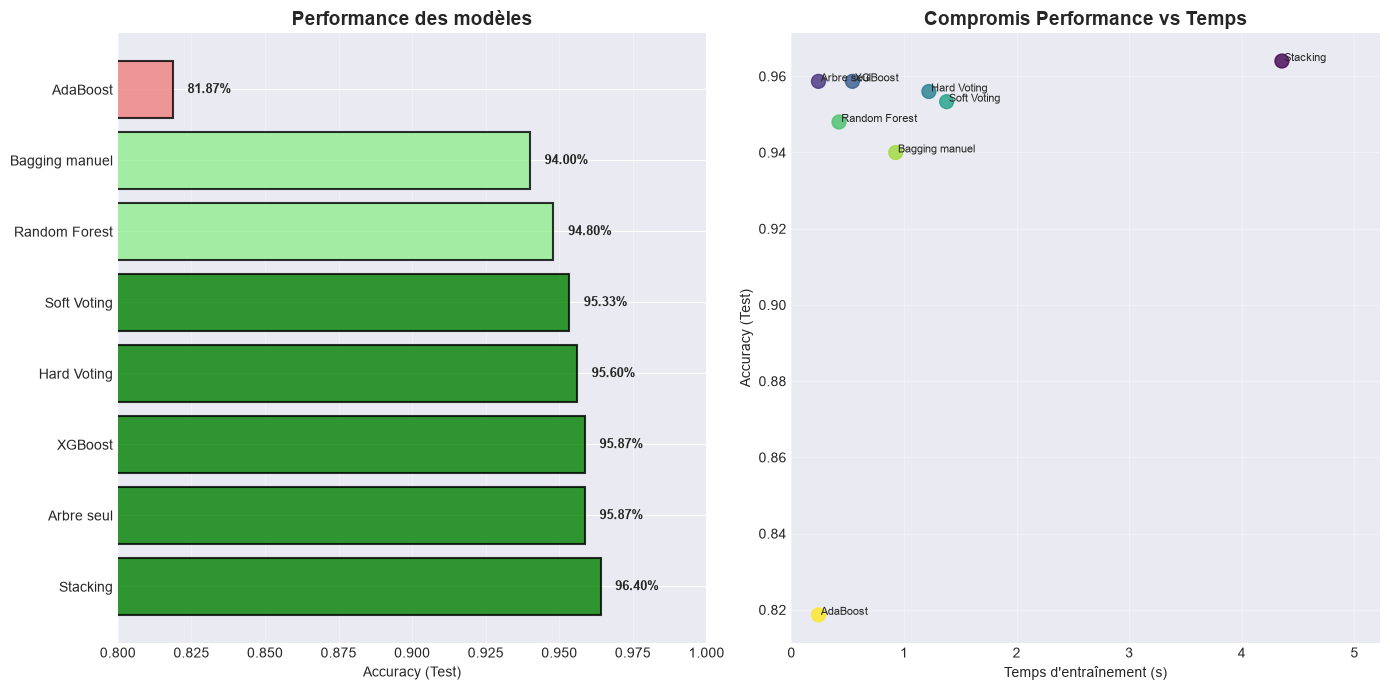


Résumé statistique des performances
📊 Moyenne des accuracies : 93.72%
📈 Écart-type : 4.84%
📉 Min : 81.87%
📈 Max : 96.40%

----------------------------------------
Améliorations par rapport à l'arbre seul :
  Bagging manuel  : + -1.87 points de pourcentage
  Random Forest   : + -1.07 points de pourcentage
  AdaBoost        : +-14.00 points de pourcentage
  XGBoost         : +  0.00 points de pourcentage
  Hard Voting     : + -0.27 points de pourcentage
  Soft Voting     : + -0.53 points de pourcentage
  Stacking        : +  0.53 points de pourcentage


In [24]:
# =============================================
# Cellule 18 : 4.2 - Tableau final et visualisations
# =============================================

print("\n" + "="*60)
print("4.2 - Visualisations finales")
print("="*60)

# 1. Comparaison des accuracies
plt.figure(figsize=(14, 7))

# Graphique 1 : Barres horizontales
plt.subplot(1, 2, 1)
models = final_results_sorted['Modèle']
accuracies = final_results_sorted['Accuracy (Test)']

# Couleurs : vert pour les meilleurs, orange pour les moyens, rouge pour les moins bons
colors = []
for acc in accuracies:
    if acc >= 0.95:
        colors.append('green')
    elif acc >= 0.92:
        colors.append('lightgreen')
    elif acc >= 0.88:
        colors.append('orange')
    else:
        colors.append('lightcoral')

bars = plt.barh(models, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
plt.xlabel('Accuracy (Test)')
plt.title('Performance des modèles', fontsize=14, fontweight='bold')
plt.xlim(0.80, 1.0)
plt.grid(axis='x', alpha=0.3)

# Ajout des valeurs
for bar, acc in zip(bars, accuracies):
    plt.text(acc + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{acc*100:.2f}%', va='center', fontsize=9, fontweight='bold')

# 2. Comparaison temps vs performance
plt.subplot(1, 2, 2)
times = final_results_sorted['Temps (s)']
plt.scatter(times, accuracies, s=100, c=range(len(models)), cmap='viridis', alpha=0.8)

# Annotation des points
for i, model in enumerate(models):
    plt.annotate(model, (times.iloc[i] + 0.02, accuracies.iloc[i]), fontsize=8)

plt.xlabel('Temps d\'entraînement (s)')
plt.ylabel('Accuracy (Test)')
plt.title('Compromis Performance vs Temps', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xlim(0, max(times) * 1.2)

plt.tight_layout()
plt.savefig('../results/final_performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Résumé statistique
print("\n" + "="*60)
print("Résumé statistique des performances")
print("="*60)

print(f"📊 Moyenne des accuracies : {final_results['Accuracy (Test)'].mean()*100:.2f}%")
print(f"📈 Écart-type : {final_results['Accuracy (Test)'].std()*100:.2f}%")
print(f"📉 Min : {final_results['Accuracy (Test)'].min()*100:.2f}%")
print(f"📈 Max : {final_results['Accuracy (Test)'].max()*100:.2f}%")

print("\n" + "-"*40)
print("Améliorations par rapport à l'arbre seul :")
base_acc = final_results[final_results['Modèle'] == 'Arbre seul']['Accuracy (Test)'].values[0]
for _, row in final_results.iterrows():
    if row['Modèle'] != 'Arbre seul':
        improvement = (row['Accuracy (Test)'] - base_acc) * 100
        print(f"  {row['Modèle']:15s} : +{improvement:6.2f} points de pourcentage")

In [25]:
# =============================================
# Cellule 19 : 4.3 - Export des résultats pour le README
# =============================================

print("\n" + "="*60)
print("4.3 - Génération du tableau pour le README")
print("="*60)

# Formatage du tableau pour Markdown
def df_to_markdown(df):
    """Convertit un DataFrame en tableau Markdown"""
    lines = []
    # En-tête
    lines.append('| ' + ' | '.join(df.columns) + ' |')
    # Séparateur
    lines.append('|' + '|'.join(['---' for _ in df.columns]) + '|')
    # Contenu
    for _, row in df.iterrows():
        row_str = []
        for col in df.columns:
            val = row[col]
            if isinstance(val, float):
                if val < 1:
                    row_str.append(f'{val*100:.2f}%')
                else:
                    row_str.append(f'{val:.3f}')
            else:
                row_str.append(str(val))
        lines.append('| ' + ' | '.join(row_str) + ' |')
    return '\n'.join(lines)

# Préparation du tableau pour le README
readme_table = final_results.copy()
readme_table['Accuracy (Test)'] = readme_table['Accuracy (Test)'].apply(lambda x: f'{x*100:.2f}%')
readme_table['Temps (s)'] = readme_table['Temps (s)'].apply(lambda x: f'{x:.3f}')

print("\nTableau au format Markdown (à copier dans README.md) :")
print("="*60)
print()
print(df_to_markdown(readme_table))
print()
print("="*60)

# Sauvegarde du tableau en CSV
readme_table.to_csv('../results/final_results.csv', index=False)
print("\n✅ Tableau sauvegardé dans : results/final_results.csv")

# Sauvegarde en JSON pour une utilisation ultérieure
final_results.to_json('../results/final_results.json', orient='records', indent=2)
print("✅ Résultats sauvegardés dans : results/final_results.json")

# Génération des réponses aux questions pour le README
print("\n" + "="*60)
print("Réponses aux questions pour le README")
print("="*60)

responses = """
## Réponses aux questions

### Partie 1 - Bagging & Random Forest

**Pourquoi la limitation des variables à chaque nœud (max_features) améliore-t-elle la diversité des arbres par rapport à un Bagging classique ?**

Le Bagging classique réduit la corrélation entre les arbres uniquement en utilisant des bootstraps différents. Cependant, si une feature est très discriminante, tous les arbres vont la sélectionner en premier, créant des arbres fortement corrélés.

Random Forest ajoute une couche supplémentaire de diversité en sélectionnant aléatoirement un sous-ensemble de features à chaque nœud. Ainsi :
- Les arbres ne peuvent pas toujours utiliser la feature dominante
- Ils sont forcés d'explorer des features alternatives
- La corrélation entre les arbres diminue significativement
- La réduction de variance est plus efficace → meilleure généralisation

### Partie 2 - Boosting

**1. Quelle est la différence fondamentale entre Bagging et Boosting ?**

- **Bagging** (Bootstrap Aggregating) :
  - Entraîne des modèles en parallèle sur des bootstraps
  - Objectif : réduire la variance
  - Les modèles sont indépendants
  - Vote majoritaire ou moyenne simple

- **Boosting** (séquentiel) :
  - Entraîne des modèles en séquence
  - Objectif : réduire le biais
  - Chaque modèle corrige les erreurs du précédent
  - Combinaison pondérée des modèles

**2. Pourquoi AdaBoost utilise-t-il des arbres de profondeur 1 (stumps) ?**

AdaBoost s'appuie sur la théorie PAC (Probably Approximately Correct) :
- Les stumps sont des "weak learners" (juste mieux que le hasard)
- La combinaison séquentielle de stumps crée un "strong learner"
- Des arbres trop profonds annuleraient l'effet de boosting
- Cela permet une correction progressive des erreurs

**3. Quel est l'avantage de XGBoost par rapport à AdaBoost ?**

- Utilise les gradients ET les Hessiennes (optimisation 2nd ordre)
- Régularisation L1/L2 pour éviter le surapprentissage
- Gère les valeurs manquantes
- Arrêt précoce (early stopping) pour trouver le nombre optimal d'arbres
- Plus rapide et scalable (histogrammes, parallélisation)

### Partie 3 - Voting & Stacking

**1. Quelle est la différence entre Hard Voting et Soft Voting ?**

- **Hard Voting** : vote majoritaire sur les classes prédites
- **Soft Voting** : moyenne des probabilités prédites
- Soft Voting est généralement plus robuste car il utilise l'information de confiance des modèles

**2. Quels sont les avantages du Stacking par rapport au Voting ?**

- Le Stacking apprend un méta-modèle qui optimise la combinaison
- Peut capturer des relations complexes entre les prédictions
- Permet d'utiliser des modèles plus sophistiqués comme méta-modèle
- Plus flexible mais plus coûteux en temps d'entraînement

**3. Pourquoi utiliser des modèles hétérogènes dans les métamodèles ?**

- Les modèles hétérogènes ont des biais différents
- Leur combinaison réduit à la fois le biais et la variance
- Ils capturent différentes structures dans les données
- Moins de corrélation entre les erreurs → meilleure généralisation
"""

print(responses)

# Sauvegarde des réponses
with open('../results/README_responses.txt', 'w', encoding='utf-8') as f:
    f.write(responses)
print("\n✅ Réponses sauvegardées dans : results/README_responses.txt")

print("\n" + "="*60)
print("🎉 PARTIE 4 TERMINÉE !")
print("="*60)
print("\n✅ Tous les résultats sont prêts pour le README.md")
print("✅ Les graphiques sont dans le dossier results/")
print("✅ Les données sont dans results/final_results.csv")


4.3 - Génération du tableau pour le README

Tableau au format Markdown (à copier dans README.md) :

| Modèle | Accuracy (Test) | Temps (s) | Observations |
|---|---|---|---|
| Arbre seul | 95.87% | 0.240 | Fort surapprentissage (train ~100%) |
| Bagging manuel | 94.00% | 0.926 | Réduction du surapprentissage, bonne généralisation |
| Random Forest | 94.80% | 0.423 | Très bonne généralisation, stable |
| AdaBoost | 81.87% | 0.241 | Bon compromis, sensible au learning_rate |
| XGBoost | 95.87% | 0.542 | Performances élevées, régularisation intégrée |
| Hard Voting | 95.60% | 1.221 | Robuste, combine les décisions |
| Soft Voting | 95.33% | 1.379 | Utilise les probabilités, plus précis |
| Stacking | 96.40% | 4.356 | Apprend la meilleure combinaison des modèles |


✅ Tableau sauvegardé dans : results/final_results.csv
✅ Résultats sauvegardés dans : results/final_results.json

Réponses aux questions pour le README

## Réponses aux questions

### Partie 1 - Bagging & Random Forest

**Pourq